In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##### Load Excel

In [8]:
df_plot_heatmap = pd.read_excel("Total_result_mcq.xlsx")

In [9]:
# Identify runs
runs = [1, 2, 3]

In [10]:
# Compute accuracy per (model, run)
records = []
for model, g in df_plot_heatmap.groupby("model"):
    for r in runs:
        acc = g[f"is_correct_run_{r}"].mean()
        records.append({"model": model, "run": f"run_{r}", "accuracy": acc})

acc_df = pd.DataFrame(records)

# Pivot to matrix: rows = run, columns = model
heatmap_df_accuracy = acc_df.pivot(index="run", columns="model", values="accuracy")

In [11]:
# Build records with time taken
records = []
for model, g in df_plot_heatmap.groupby("model"):
    for r in runs:
        t = g[f"time_taken_run_{r}"].mean()
        records.append({"model": model, "run": f"run_{r}", "time_taken": t})

# Create dataframe
time_df = pd.DataFrame(records)

# Pivot for heatmap
heatmap_df_time = time_df.pivot(index="run", columns="model", values="time_taken")


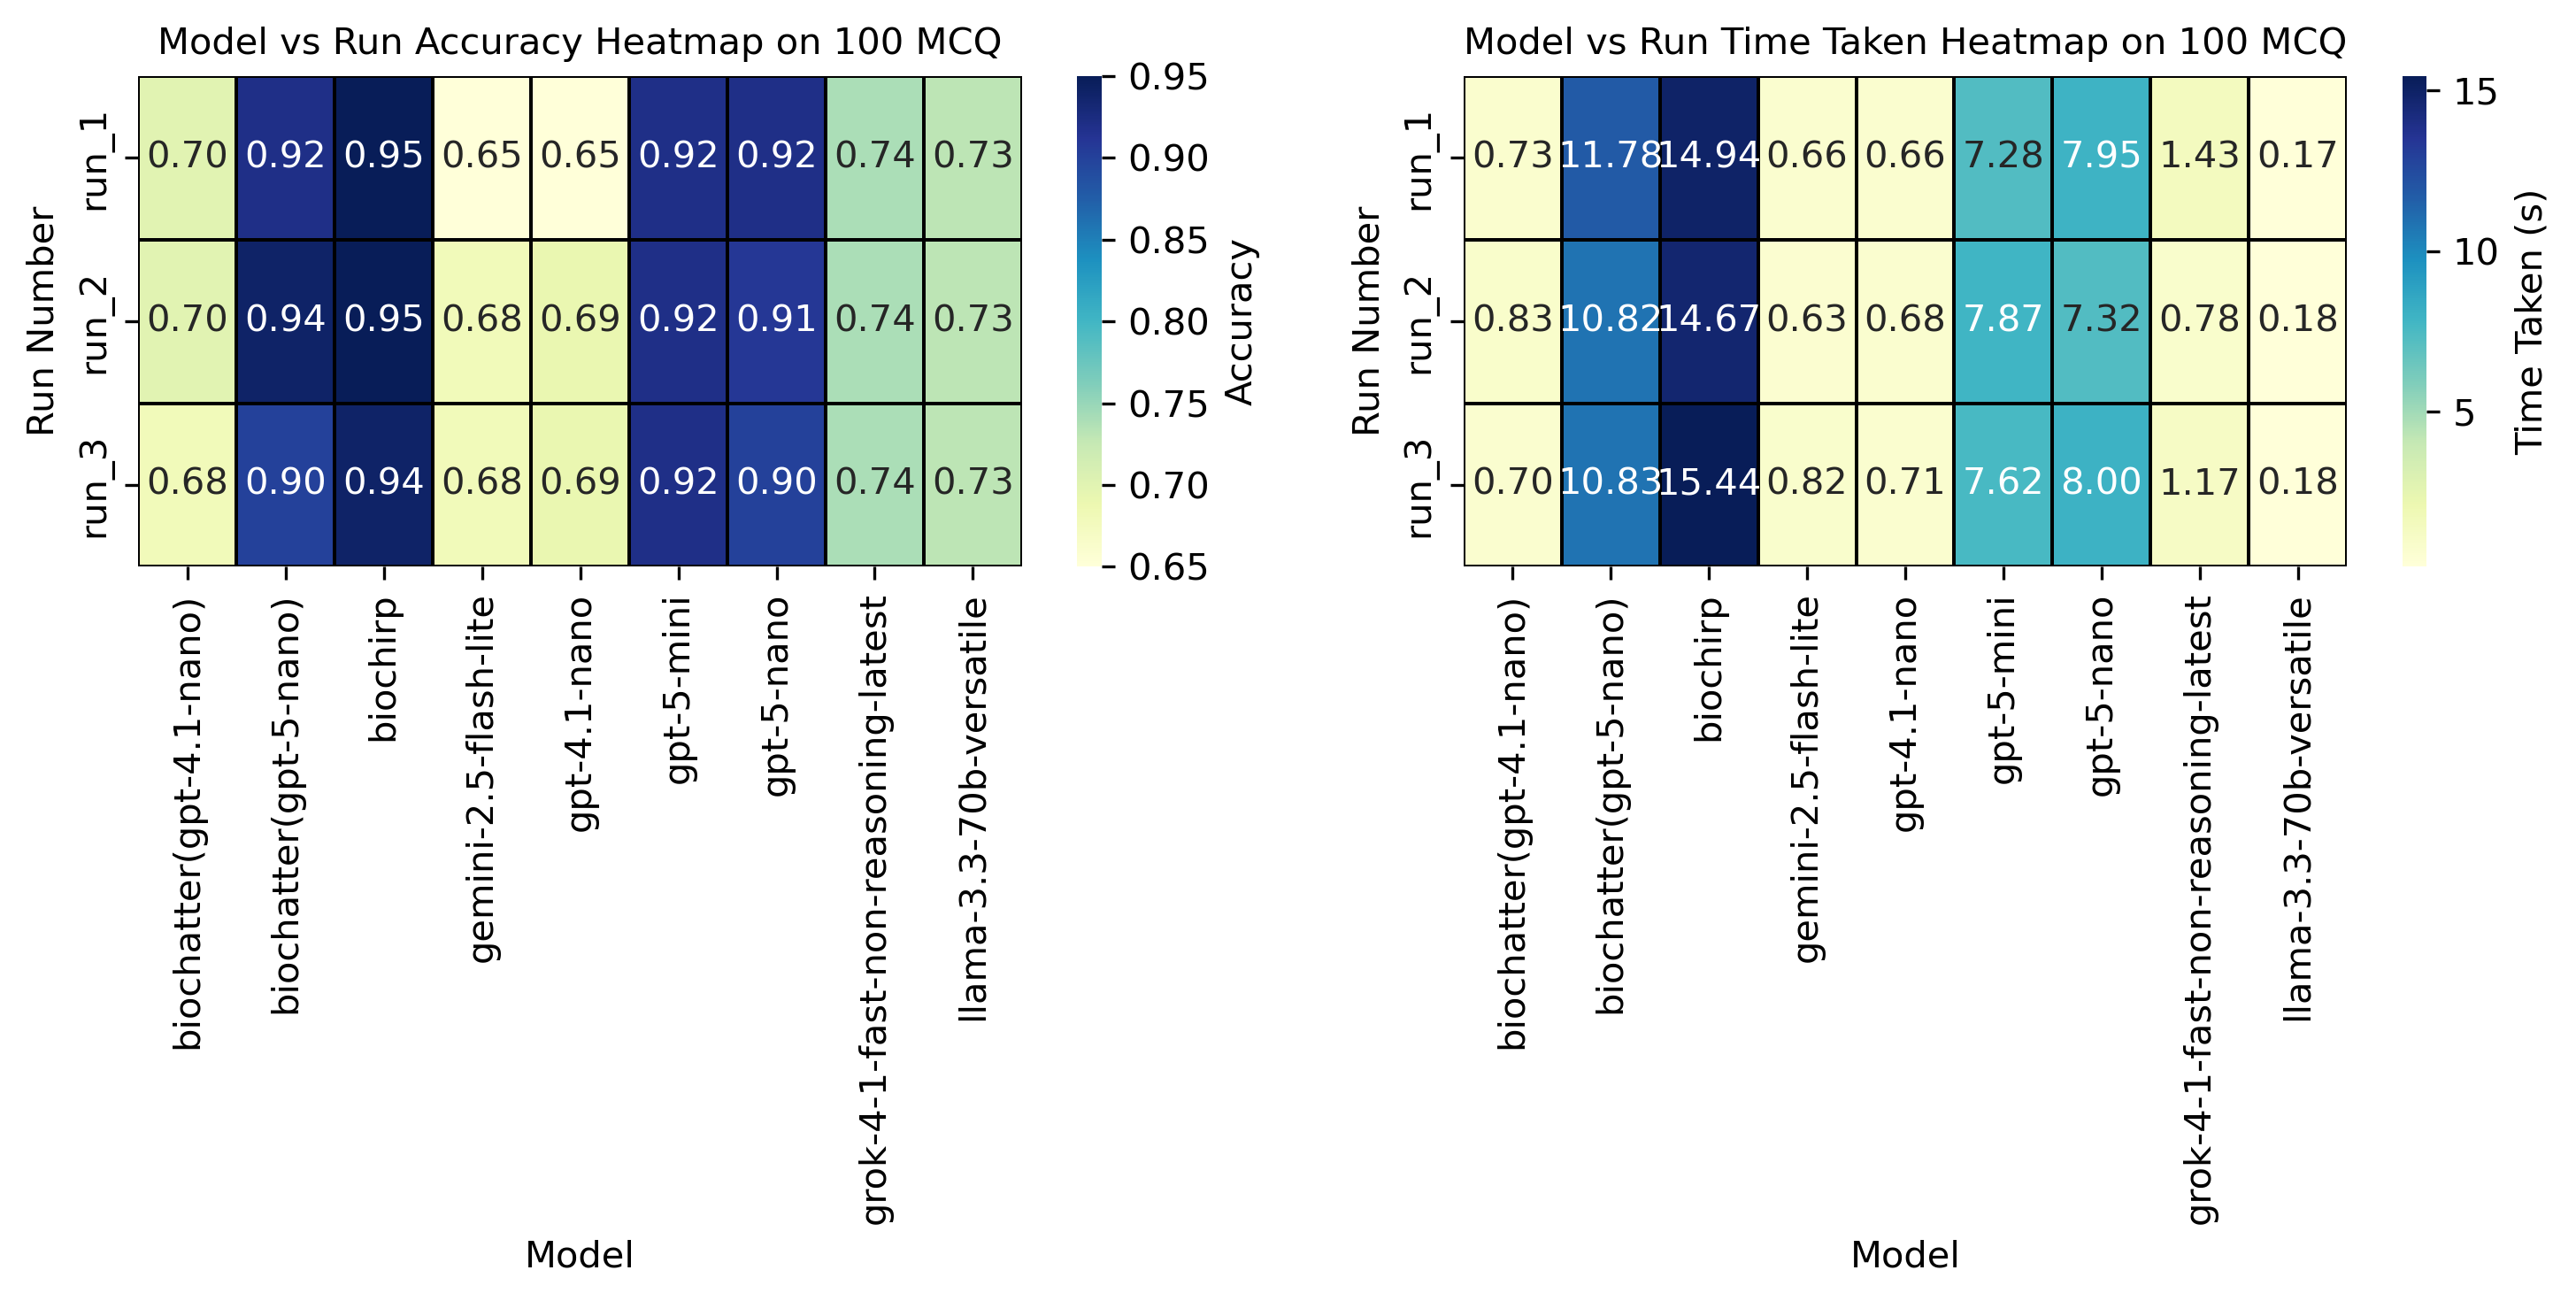

In [12]:
fig, ax = plt.subplots(1,2, figsize = (10, 5), dpi = 300)

# plt.figure(figsize=(6, 6))
# sns.set(style="whitegrid")

ax[0] = sns.heatmap(
    heatmap_df_accuracy,
    annot=True,                  # Show accuracy values
    fmt=".2f",                   # Format floats to 2 decimal places
    cmap="YlGnBu",               # Better perceptual color gradient
    linewidths=0.5,              # Borders between cells
    linecolor="black",           # Border color
    cbar_kws={"label": "Accuracy"},
    annot_kws={"size": 10}, ax=ax[0]
)

# Axis labels and title
ax[0].set_xlabel("Model")
ax[0].set_ylabel("Run Number")
ax[0].set_title("Model vs Run Accuracy Heatmap on 100 MCQ", fontsize=10)


ax[1] = sns.heatmap(
    heatmap_df_time,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",               # Choose better colormap for time (e.g. "Oranges", "coolwarm")
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"label": "Time Taken (s)"},
    annot_kws={"size": 10}, ax =ax[1]
)

# Labels and ticks
ax[1].set_xlabel("Model")
ax[1].set_ylabel("Run Number")
ax[1].set_title("Model vs Run Time Taken Heatmap on 100 MCQ", fontsize=10)

plt.tight_layout()
# plt.show()
